In [15]:
# !pip install deepxde

In [16]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt


In [17]:
omega = 2.0

def pde(t, u):
    d2u_dt2 = dde.grad.hessian(u, t)
    return d2u_dt2 + omega**2 * u

In [ ]:
geom = dde.geometry.TimeDomain(0, 10)

def expected_position(t): # For A
    return np.ones((len(t), 1))


def is_at_initial_time(x, on_boundary):
    return on_boundary and np.isclose(x[0], 0.0)

# ✅ Clear and correct
def velocity_operator(inputs, outputs, X): # Automatically asign u'(t) = 0
    du_dt = dde.grad.jacobian(outputs, inputs)
    return du_dt


ic = dde.IC(geom, expected_position, is_at_initial_time)
ic_dc = dde.OperatorBC(geom, velocity_operator, is_at_initial_time)


In [19]:
data = dde.data.TimePDE(
    geom,
    pde,
    [ic, ic_dc],
    num_domain=200,
    num_boundary=2,
    num_test=1000
)


net = dde.nn.FNN([1] + [50] * 3 + [1], "tanh", "Glorot normal")

model = dde.Model(data, net)



In [20]:
model.compile("adam", lr=1e-3)
model.train(iterations=10000, display_every=100)


print("Training with L-BFGS...")
model.compile("L-BFGS")
model.train(display_every=100)

Compiling model...
'compile' took 0.012264 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [1.11e+00, 1.00e+00, 4.18e-05]    [1.12e+00, 1.00e+00, 4.18e-05]    []  
100       [1.93e-01, 3.40e-01, 4.43e-02]    [1.75e-01, 3.40e-01, 4.43e-02]    []  
200       [1.79e-01, 2.54e-01, 2.32e-02]    [1.64e-01, 2.54e-01, 2.32e-02]    []  
300       [1.92e-01, 1.01e-01, 8.36e-04]    [1.82e-01, 1.01e-01, 8.36e-04]    []  
400       [1.82e-01, 7.67e-02, 1.26e-04]    [1.78e-01, 7.67e-02, 1.26e-04]    []  
500       [1.73e-01, 6.38e-02, 4.11e-05]    [1.73e-01, 6.38e-02, 4.11e-05]    []  
600       [1.68e-01, 5.59e-02, 3.18e-05]    [1.69e-01, 5.59e-02, 3.18e-05]    []  
700       [1.60e-01, 5.13e-02, 4.99e-05]    [1.61e-01, 5.13e-02, 4.99e-05]    []  
800       [1.52e-01, 4.56e-02, 4.04e-05]    [1.53e-01, 4.56e-02, 4.04e-05]    []  
900       [1.47e-01, 3.93e-02, 1.26e-05]    [1.47e-01, 3.93e-02, 1.26e-05]    []  
1000      [1.46

(<deepxde.model.LossHistory at 0x7ac932be7620>,
 <deepxde.model.TrainState at 0x7ac938666b40>)

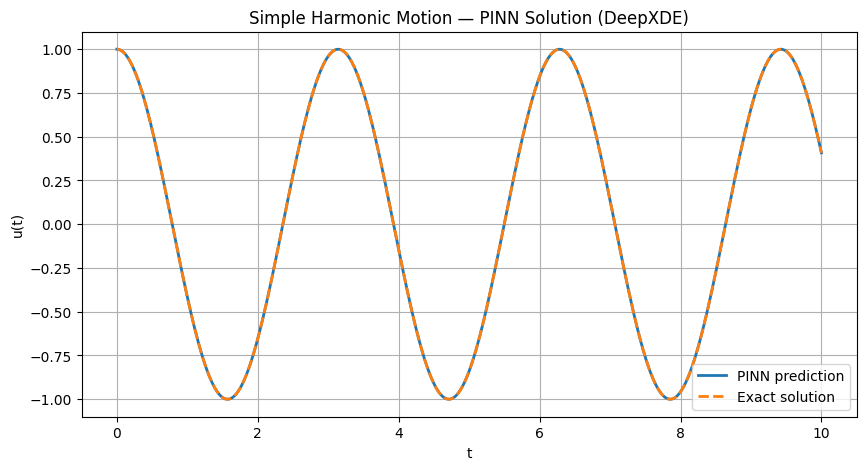

In [21]:
# ── 8. Visualize the Solution ──────────────────────────────────────
t = np.linspace(0, 10, 1000).reshape(-1, 1)

# Predict u(t)
u_pred = model.predict(t)

# Exact solution: u(t) = cos(omega * t)
u_exact = np.cos(omega * t)

plt.figure(figsize=(10, 5))
plt.plot(t, u_pred, label="PINN prediction", linewidth=2)
plt.plot(t, u_exact, "--", label="Exact solution", linewidth=2)
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Simple Harmonic Motion — PINN Solution (DeepXDE)")
plt.legend()
plt.grid(True)
plt.show()